/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_33253/4234888493.py:187: RuntimeWarning: divide by zero encountered in power
  return inv2**(-0.5)


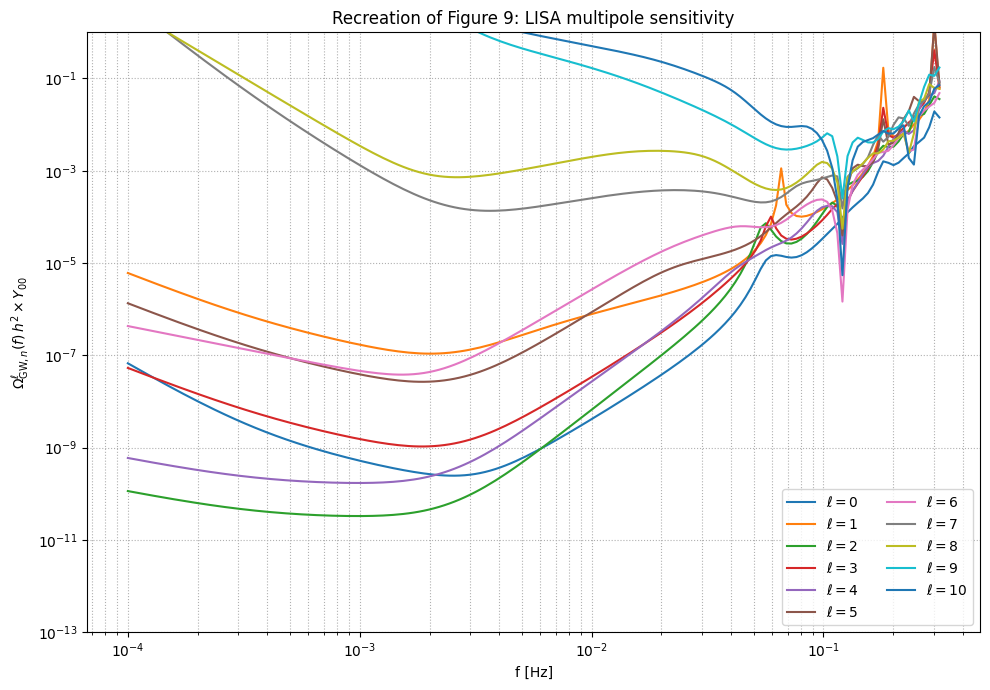

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from schnell.mapping import MapCalculator
from schnell.detector import LISADetector

C_LIGHT = 299792458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0 * np.pi * L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M  # s^-1

P_OMS_PM = 15.0  # pm
A_ACC_FM = 3.0   # fm/s^2


def S_oms(f):
    f = np.asarray(f, dtype=float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, dtype=float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = (1.0 - cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 - cosx)**2 * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc

def alm_row_mge0(alm, lmax, ell):
    out = np.zeros(ell + 1, dtype=np.complex128)
    for m in range(0, ell + 1):
        out[m] = alm[hp.Alm.getidx(lmax, ell, m)]
    return out

def sum_over_m_pm_even(weight_mge0, val_mge0):
    # sum_{m=-ell..ell} w(m)|val(m)|^2 for even weights
    total = weight_mge0[0] * np.abs(val_mge0[0])**2
    if len(val_mge0) > 1:
        total += 2.0 * np.sum(weight_mge0[1:] * np.abs(val_mge0[1:])**2)
    return total


def Rell_channels_from_alms(R11_alm, R12_alm, lmax, ell):
    m = np.arange(0, ell + 1)

    R11 = alm_row_mge0(R11_alm, lmax, ell)
    R12 = alm_row_mge0(R12_alm, lmax, ell)

    # Enforce ℓ+m even selection rule (paper Eq. 4.21):
    allowed = ((ell + m) % 2 == 0)
    R11 = np.where(allowed, R11, 0.0)
    R12 = np.where(allowed, R12, 0.0)

    cos_2m = np.cos(2.0 * m * np.pi / 3.0)
    sin2_m = np.sin(m * np.pi / 3.0)**2

    out = {}

    if ell % 2 == 1:
        out["AA"] = 0.0
        out["EE"] = 0.0
        out["TT"] = 0.0

        w_AE = (1.0 + 2.0 * cos_2m)**2
        out["AE"] = np.sqrt((1.0/3.0) * sum_over_m_pm_even(w_AE, R12))

        w_AT = sin2_m
        out["AT"] = np.sqrt(2.0 * sum_over_m_pm_even(w_AT, R12))
        out["ET"] = out["AT"]

    else:
        phase_m4 = (1.0 + np.exp(-4j * m * np.pi / 3.0))
        phase_p2 = (1.0 + np.exp( 2j * m * np.pi / 3.0))

        val_AA = phase_m4 * R11 - 2.0 * R12
        out["AA"] = np.sqrt((1.0/4.0) * sum_over_m_pm_even(np.ones_like(m), val_AA))
        out["EE"] = out["AA"]

        w_TT = (1.0 + 2.0 * cos_2m)**2
        val_TT = (R11 + 2.0 * R12)
        out["TT"] = np.sqrt((1.0/9.0) * sum_over_m_pm_even(w_TT, val_TT))

        w_AE = sin2_m
        val_AE = phase_p2 * R11 - 2.0 * R12
        out["AE"] = np.sqrt((1.0/3.0) * sum_over_m_pm_even(w_AE, val_AE))

        w_AT = sin2_m
        val_AT = phase_p2 * R11 + R12
        out["AT"] = np.sqrt((2.0/3.0) * sum_over_m_pm_even(w_AT, val_AT))
        out["ET"] = out["AT"]

    return out

def omega_from_pair_threshold(f_grid, Rv, N1, N2, rel_thr=1e-12):
    """
    Compute Ω_n(f) for one channel-pair using Eq. (4.42), but
    set Ω_n = +inf where the response is too close to zero.

    rel_thr is a relative threshold on Rv compared to max(Rv).
    """
    Rv = np.asarray(Rv, dtype=float)
    N1 = np.asarray(N1, dtype=float)
    N2 = np.asarray(N2, dtype=float)

    # relative threshold to avoid spikes when R -> 0
    Rmax = np.max(Rv)
    thr = rel_thr * Rmax if Rmax > 0 else np.inf

    om = np.full_like(f_grid, np.inf, dtype=float)
    mask = Rv > thr
    if np.any(mask):
        om[mask] = omega_channel_channel_tilde(
            f_grid[mask],
            Rv[mask],
            N1[mask],
            N2[mask],
        )
    return om

def map2alm_complex(hp_map, lmax, iter=5):
    hp_map = np.asarray(hp_map)
    alm_re = hp.map2alm(np.real(hp_map), lmax=lmax, iter=iter)
    alm_im = hp.map2alm(np.imag(hp_map), lmax=lmax, iter=iter)
    return alm_re + 1j * alm_im



def compute_Rlm_11_12(
    f_grid, lmax=10, nside=64, t0=0.0,
    calibrate=False, f_cal=1e-5, R0AA_target=9.0/20.0
):
    f_grid = np.asarray(f_grid, dtype=float)

    dets = [LISADetector(detector_id=i) for i in range(3)]
    mc = MapCalculator(dets)

    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    def antenna_alm(i, j, f):
        ant = mc.get_antenna(i, j, t0, float(f), theta, phi, pol=False, inc_baseline=True)
        ant = np.asarray(ant).squeeze()
        if ant.shape != (npix,):
            raise RuntimeError(f"get_antenna returned {ant.shape} (expected {(npix,)}) dtype {ant.dtype}")
        alm = map2alm_complex(ant, lmax=lmax, iter=5)

        alm = alm / (8.0 * np.pi)
        return alm

    scale = 1.0
    alm11_list = []
    alm12_list = []
    for f in f_grid:
        alm11_list.append(antenna_alm(0, 0, f) * scale)
        alm12_list.append(antenna_alm(0, 1, f) * scale)

    return alm11_list, alm12_list



def omega_combined_from_channels(omega_auto, omega_cross):
    """
    omega_auto  = [Ω_AA, Ω_EE, Ω_TT]
    omega_cross = [Ω_AE, Ω_AT, Ω_ET]
    Implements sum_{O,O'} (1/Ω_{OO'})^2 with ordered pairs:
      autos counted once, crosses counted twice.
    """
    inv2 = np.zeros_like(omega_auto[0], dtype=float)
    for om in omega_auto:
        inv2 += 1.0 / (om**2)
    for om in omega_cross:
        inv2 += 1.0 / (om**2)
    return inv2**(-0.5)


def omega_channel_channel_tilde(f, Rtilde_ell, Ntilde1, Ntilde2):
    pref = (4.0 * np.pi**2 * np.sqrt(4.0 * np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) *(np.sqrt(Ntilde1 * Ntilde2) / (Rtilde_ell))



def recreate_figure9(f_grid, lmax=10, nside=64):
    f_grid = np.asarray(f_grid, dtype=float)

    alm11_list, alm12_list = compute_Rlm_11_12(
        f_grid, lmax=lmax, nside=nside, t0=0.0, calibrate=False, f_cal=1e-5
    )

    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    Y00 = 1.0 / np.sqrt(4.0 * np.pi)

    omega_ell = {}

    for ell in range(lmax + 1):

        Rell = {key: np.zeros_like(f_grid, dtype=float) for key in ["AA", "EE", "TT", "AE", "AT", "ET"]}

        for i_f in range(len(f_grid)):
            Rch = Rell_channels_from_alms(alm11_list[i_f], alm12_list[i_f], lmax=lmax, ell=ell)
            for k, v in Rch.items():
                Rell[k][i_f] = float(np.abs(v))

        omega_auto = []
        for O in ["A", "E", "T"]:
            key = O + O
            omega_auto.append(
                omega_from_pair_threshold(f_grid, Rell[key], N_map[O], N_map[O], rel_thr=1e-12)
            )
                
        omega_cross = []
        for (O1, O2, key) in [("A", "E", "AE"), ("A", "T", "AT"), ("E", "T", "ET")]:
            omega_cross.append(
                omega_from_pair_threshold(f_grid, Rell[key], N_map[O1], N_map[O2], rel_thr=1e-12)
            )
                        
        omega_comb = omega_combined_from_channels(omega_auto, omega_cross)
        omega_ell[ell] = omega_comb * Y00

    return omega_ell


f = np.logspace(-4, -0.5, 160)
curves = recreate_figure9(f, lmax=10, nside=64)

plt.figure(figsize=(10, 7))
for ell in range(0, 11):
    plt.loglog(f, curves[ell], label=fr"$\ell={ell}$")

plt.xlabel("f [Hz]")
plt.ylim([1e-13, 1e0])
plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 \times Y_{00}$")
plt.title("Recreation of Figure 9: LISA multipole sensitivity")
plt.grid(True, which="both", ls=":")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()